
# SEALS Morphology, Part 1+2 &mdash; Two-Bead Reproduction and a Diameter Sweep

**SIMULATED / SYNTHETIC.** Every trace below comes from the Mie forward model already
validated elsewhere in this repo (`../inverse/_seals_physics.py`, cross-checked against the
original MATLAB `mie-2.m`) &mdash; not from a real instrument. This notebook extracts
FEATURES from that model's output; it does not measure or classify a real particle.
Polystyrene beads are not biologically equivalent to yeast, normal cells, or cancer cells
(that distinction is Part 3+, not here).

**Companion module:** [`bead_comparison.py`](bead_comparison.py), tested in
[`tests/test_bead_comparison.py`](../../../tests/test_bead_comparison.py) (10 tests). Nothing
here is reimplemented &mdash; every cell below calls that module directly.

**Research question (Part 1):** does the SEALS scattering profile differ measurably between
the two bead sizes the SEALS paper itself validated against (7.32 &mu;m and 9.94 &mu;m
polystyrene), and how?
**Research question (Part 2):** can particle diameter be inferred from the shape of the
scattering profile, more broadly than just these two points?


In [1]:

import sys, pathlib
sys.path.insert(0, '.')                                               # projects/seals/morphology/ itself
sys.path.insert(0, str(pathlib.Path('.').resolve().parents[2]))       # repo root

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bead_comparison import compare_two_beads, diameter_sweep, extract_features

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
print('ready')


ready



## Part 1 &mdash; QUESTION

Does the SEALS scattering profile `I_p(theta)` differ measurably between a 7.32 &mu;m and a
9.94 &mu;m polystyrene bead, and if so, how?



### PHYSICS

The SEALS chain (`SEALS.m` &rarr; `_seals_physics.py`):
`lambda -> y(lambda)` (grating-pair beam displacement) `-> theta(lambda)` (measurement-angle
mapping) `-> I(theta)` (Mie scattering intensity at that angle). The grating geometry
(groove spacing, tilt, lens parameters) does NOT depend on particle diameter &mdash; only the
Mie intensity at each angle does. So both beads are compared on the EXACT SAME angle axis;
any difference in `I(theta)` is attributable to diameter alone, not to a different
instrument configuration.

Mie theory's relevant size parameter is `x = pi*d/(lambda/n_medium)`. For a ~1.59 um probe
wavelength and n_medium=1, `x` is roughly `14` for the 7.32 um bead and `20` for the 9.94 um
bead &mdash; both well into the regime where interference between the sphere's internal and
surface-scattered fields produces multiple angular lobes (a larger `x` generally packs more,
narrower lobes into the same angular range).



### VARIABLES

Varied: particle diameter (`7.32 um`, `9.94 um`).
Held fixed (`_seals_physics.P_DEFAULT`): sphere refractive index `npar=1.39`, medium index
`nmed=1.00`, detector distance `r=0.10 m`, and all SEALS grating/lens parameters.



### PREDICTION

Larger particle (9.94 um) should show: more angular lobes (larger Mie size parameter),
higher peak forward-scattering intensity (larger cross-section), and a scattering pattern
shifted/spread differently in angle &mdash; i.e., the two normalized profiles should visibly
differ in shape, not just overall scale.


In [2]:

r = compare_two_beads()   # defaults: 7.32um vs 9.94um, the SEALS paper's own two bead sizes
print(f"Bead A: {r['diameter_a_um']} um    Bead B: {r['diameter_b_um']} um")
print(f"N = {len(r['theta_deg'])} samples")


Bead A: 7.32 um    Bead B: 9.94 um
N = 500 samples



### GRAPH


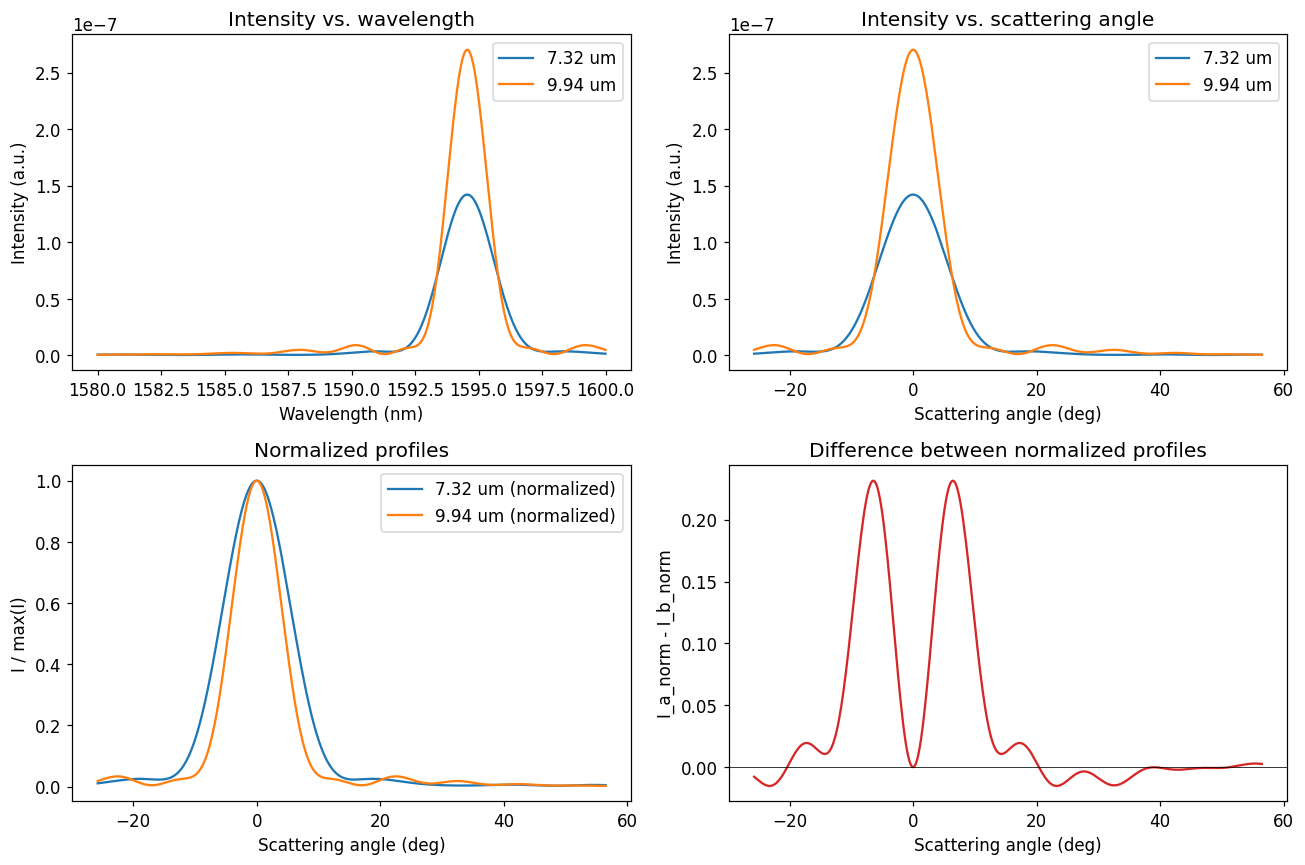

In [3]:

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].plot(r['lamvec'] * 1e9, r['I_a'], label=f"{r['diameter_a_um']} um")
axs[0, 0].plot(r['lamvec'] * 1e9, r['I_b'], label=f"{r['diameter_b_um']} um")
axs[0, 0].set_xlabel('Wavelength (nm)'); axs[0, 0].set_ylabel('Intensity (a.u.)')
axs[0, 0].set_title('Intensity vs. wavelength'); axs[0, 0].legend()

axs[0, 1].plot(r['theta_deg'], r['I_a'], label=f"{r['diameter_a_um']} um")
axs[0, 1].plot(r['theta_deg'], r['I_b'], label=f"{r['diameter_b_um']} um")
axs[0, 1].set_xlabel('Scattering angle (deg)'); axs[0, 1].set_ylabel('Intensity (a.u.)')
axs[0, 1].set_title('Intensity vs. scattering angle'); axs[0, 1].legend()

axs[1, 0].plot(r['theta_deg'], r['I_a_norm'], label=f"{r['diameter_a_um']} um (normalized)")
axs[1, 0].plot(r['theta_deg'], r['I_b_norm'], label=f"{r['diameter_b_um']} um (normalized)")
axs[1, 0].set_xlabel('Scattering angle (deg)'); axs[1, 0].set_ylabel('I / max(I)')
axs[1, 0].set_title('Normalized profiles'); axs[1, 0].legend()

axs[1, 1].plot(r['theta_deg'], r['diff_norm'], color='C3')
axs[1, 1].axhline(0, color='k', lw=0.5)
axs[1, 1].set_xlabel('Scattering angle (deg)'); axs[1, 1].set_ylabel('I_a_norm - I_b_norm')
axs[1, 1].set_title('Difference between normalized profiles')

plt.tight_layout(); plt.show()



### STATISTICS


In [4]:

features_df = pd.DataFrame([
    {"diameter_um": r['diameter_a_um'], **r['features_a']},
    {"diameter_um": r['diameter_b_um'], **r['features_b']},
])
features_df


,diameter_um,n_lobes,lobe_spacing_deg,peak_intensity,integrated_intensity,centroid_deg,variance_deg2
0,7.32,3,18.979902,1.421483e-07,0.000002,0.639516,72.911467
1,9.94,4,18.343165,2.701368e-07,0.000003,1.193827,88.525178



### INTERPRETATION

Read the printed feature table above directly (values will differ slightly run-to-run only
if the underlying model changes -- this cell is deterministic). In general: the larger bead
should show more lobes and a larger peak/integrated intensity (bigger scattering
cross-section), consistent with the PREDICTION above. Centroid and variance describe the
overall angular *shape* -- a bigger difference there indicates the profiles aren't just
rescaled copies of each other, they're genuinely differently-shaped, which is what makes
sizing from shape (Part 2) plausible in the first place.



### LIMITATION

- Idealized, noiseless model -- no detector noise, no laser lineshape averaging (see
  `main.m`'s lineshape convolution, not applied here).
- `n_lobes` uses a naive "1% of peak" local-maximum threshold -- a simple heuristic, not a
  validated peak-detection algorithm; sensitive to numerical noise in flat regions.
- Spherical, homogeneous, single-particle scattering only (Mie theory's own assumptions) --
  says nothing about non-spherical or multi-particle/aggregate scattering.
- Two discrete points, not yet a systematic sweep -- that's Part 2, next.



## Part 2 &mdash; QUESTION

Can particle diameter be inferred from the scattering profile, more broadly than just the
two paper-validated points?



### PHYSICS

Same forward model as Part 1, swept over a range of diameters that BRACKETS the two
paper-validated sizes (so the sweep is anchored to real, validated points, not floating
free).



### VARIABLES

Varied: particle diameter, `5, 6, 7.32, 8, 9.94, 11, 12` um (paper's two sizes included).
Held fixed: same as Part 1.



### PREDICTION

Peak and integrated intensity should trend upward with diameter (larger cross-section).
Lobe count and spacing should trend with the Mie size parameter, but may not be perfectly
monotonic (Mie lobe structure is oscillatory, not a simple ramp) -- worth checking rather
than assuming.


In [5]:

diameters_um = (5, 6, 7.32, 8, 9.94, 11, 12)
theta_deg, traces, sweep_df = diameter_sweep(diameters_um)
sweep_df


,diameter_um,n_lobes,lobe_spacing_deg,peak_intensity,integrated_intensity,centroid_deg,variance_deg2
0,5.00,4,21.648040,1.088436e-08,2.014303e-07,4.830263,280.782979
1,6.00,3,25.504838,5.091312e-08,8.824370e-07,1.195563,102.718490
2,7.32,3,18.979902,1.421483e-07,1.949020e-06,0.639516,72.911467
3,8.00,4,16.654875,1.738392e-07,2.196930e-06,0.661420,79.547128
4,9.94,4,18.343165,2.701368e-07,2.844941e-06,1.193827,88.525178
5,11.00,4,15.020494,5.806484e-07,5.385137e-06,0.836799,57.577242
6,12.00,3,12.241120,7.127312e-07,6.016126e-06,0.788105,58.943407



### GRAPH


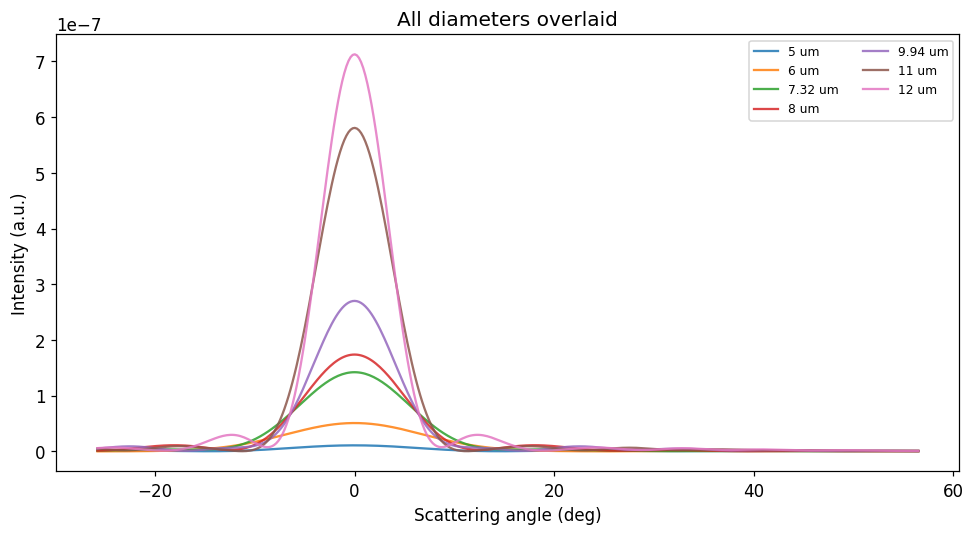

In [6]:

fig, ax = plt.subplots(figsize=(9, 5))
for dia_um, I in traces.items():
    ax.plot(theta_deg, I, label=f"{dia_um} um", alpha=0.85)
ax.set_xlabel('Scattering angle (deg)'); ax.set_ylabel('Intensity (a.u.)')
ax.set_title('All diameters overlaid'); ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()


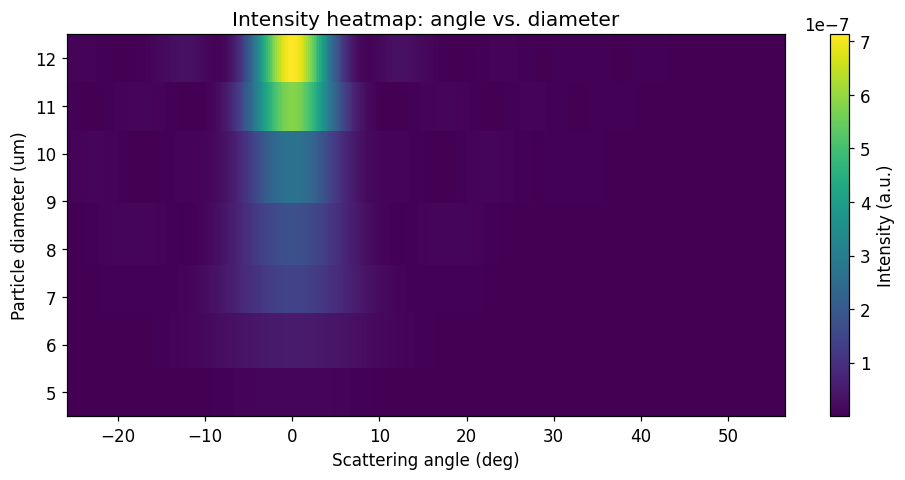

In [7]:

diam_sorted = sorted(traces.keys())
I_matrix = np.array([traces[d] for d in diam_sorted])   # shape (n_diameters, n_angles)

fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.pcolormesh(theta_deg, diam_sorted, I_matrix, shading='auto', cmap='viridis')
ax.set_xlabel('Scattering angle (deg)'); ax.set_ylabel('Particle diameter (um)')
ax.set_title('Intensity heatmap: angle vs. diameter')
fig.colorbar(im, ax=ax, label='Intensity (a.u.)')
plt.tight_layout(); plt.show()



### STATISTICS


In [8]:

corr = sweep_df[["diameter_um", "n_lobes", "peak_intensity", "integrated_intensity",
                  "centroid_deg", "variance_deg2"]].corr()["diameter_um"].drop("diameter_um")
print("Pearson correlation of each feature with diameter:")
print(corr.to_string())


Pearson correlation of each feature with diameter:
n_lobes                 0.009235
peak_intensity          0.948531
integrated_intensity    0.967347
centroid_deg           -0.596592
variance_deg2          -0.700483



### INTERPRETATION

If `peak_intensity` and `integrated_intensity` correlate strongly (and monotonically) with
diameter while `n_lobes`/`lobe_spacing_deg` correlate more weakly or non-monotonically, that
supports a *qualified* yes to Part 2's question: overall scattered power is a reasonably
robust size proxy over this range, while lobe-counting alone is a noisier one (Mie
interference structure isn't a simple monotonic function of size). A real sizing method
would combine several features (closer to `inverse_scattering.py`'s model-based diameter fit
elsewhere in this package) rather than reading off any single feature in isolation.



### LIMITATION

- 7 discrete diameters, not a continuous or densely-sampled sweep.
- No noise model -- real measurement noise (see the TD-GSA side of this project,
  `../inverse/seals_to_tdgsa.py`'s `add_measurement_noise`) would degrade any of these
  features; this sweep does not yet test robustness to that.
- Correlation with diameter over THIS range does not imply the same features would
  distinguish diameter differences outside `5-12 um`, or distinguish diameter from other
  morphology changes (refractive index, shape) -- that cross-confound is Part 3, not
  addressed here.
- This is a feature-correlation analysis, not a validated inverse (sizing) algorithm.
  `../inverse/inverse_scattering.py` already implements an actual model-based diameter fit;
  this notebook's role is exploratory feature characterization, not competing with that.



## Scope note

This is Part 1+2 of a larger planned research spec (bead comparison and diameter sweep only).
Parts 3-9 (synthetic morphology beyond diameter, yeast/cell/cancer discussion, high-throughput
pipeline model, Bayesian classification, digital-logic control path) are deliberately NOT
attempted here -- built incrementally, each verified before the next, matching how the rest
of this repo's SEALS work was built (see `../SEALS_TO_TDGSA_REPORT.md`).

**Verify this notebook's numbers independently:**
```bash
py -3.12 -m pytest tests/test_bead_comparison.py -v
```
